### Import required libraries

In [2]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import json
import time
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import mediapipe as mp
from PIL import Image

2025-10-26 19:51:33.126717: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-26 19:51:33.342915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761508293.428600    1021 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761508293.470129    1021 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761508293.695911    1021 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
# Setting up plotting style
plt.style.use('default')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Mediapipe version: {mp.__version__}")

Mediapipe version: 0.10.21


### Configuration and directory setup

In [4]:
class FacialConfig:
    IMAGE_SIZE = (224, 224)
    FACE_DETECTION_CONFIDENCE = 0.5

    USE_GRAYSCALE = False

    # data augmentation settings
    ENABLE_AUGMENTATION = True
    AUGMENTATION_FACTOR = 6 # number of augmented versions per image

    # face detection settings
    FACE_PADDING = 20 # pixels to add around detected face

config = FacialConfig()

In [5]:
# Setting project directories
BASE_DIR = Path("./multimodal_facial_data")
RAW_IMAGES_DIR = BASE_DIR / "raw_facial"
PROCESSED_FACIAL_DIR = BASE_DIR / "processed_facial"
METADATA_DIR = BASE_DIR / "metadata"

for directory in [RAW_IMAGES_DIR, PROCESSED_FACIAL_DIR, METADATA_DIR]:
    directory.mkdir(parents=True, exist_ok = True)
    print(f"Created: {directory}")

Created: multimodal_facial_data/raw_facial
Created: multimodal_facial_data/processed_facial
Created: multimodal_facial_data/metadata


In [6]:
# Emotion mapping (7 emotions)
fer_emotions = {
    0: 'angry',
    1: 'disgust',
    2: 'fear',
    3: 'happy',
    4: 'sad',
    5: 'surprise',
    6: 'neutral'
}

# Emotion color mapping for visualization
emotion_colors = {
    'angry': 'red',
    'disgust': 'green',
    'fear': 'orange',
    'happy': 'yellow',
    'sad': 'blue',
    'surprise': 'pink',
    'neutral': 'gray'
}

# Reverse mapping: emotion -> code
emotion_to_code = {v: k for k, v in fer_emotions.items()}

In [7]:
# Set up logging
def get_project_logger(name):
    logger = logging.getLogger(name)
    if not logger.hasHandlers():
        handler = logging.StreamHandler()
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        handler.setFormatter(formatter)
        logger.setLevel(logging.INFO)
    return logger

logger = get_project_logger('facial_collector')

print(f"Emotion categories: {list(fer_emotions.values())}")
print(f"Image size: {config.IMAGE_SIZE}")
print(f"Face detection confidence threshold: {config.FACE_DETECTION_CONFIDENCE}")
print(f"Base directory: {BASE_DIR}")

Emotion categories: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
Image size: (224, 224)
Face detection confidence threshold: 0.5
Base directory: multimodal_facial_data


### Manual FER-2013 Dataset Setup

In [8]:
def setup_manual_fer2013():
    fer_base_path = RAW_IMAGES_DIR / "fer2013"

    fer_train_path = fer_base_path / "train"
    fer_test_path = fer_base_path / "test"

    dataset_info = {
        'format': 'folders',
        'samples': {},
        'emotion_found': set()
    }
    total_images = 0

    # checking training data
    if fer_train_path.exists():
        train_total = 0
        for emotion_folder in fer_train_path.iterdir():
            if emotion_folder.is_dir() and emotion_folder.name in fer_emotions.values():
                # Count images
                images = (list(emotion_folder.glob("*.png")) +
                          list(emotion_folder.glob("*.jpg")) +
                          list(emotion_folder.glob("*.jpeg")))
                dataset_info['samples'][f"train_{emotion_folder.name}"] = len(images)
                dataset_info['emotion_found'].add(emotion_folder.name)
                train_total += len(images)
                total_images += len(images)
                print(f" {emotion_folder.name}: {len(images)} images")

        print(f"Total train images: {train_total}")

    
    # checking testing data
    if fer_test_path.exists():
        test_total = 0
        for emotion_folder in fer_test_path.iterdir():
            if emotion_folder.is_dir() and emotion_folder.name in fer_emotions.values():
                # counting images
                images = (list(emotion_folder.glob("*.png")) +
                          list(emotion_folder.glob("*.jpg")) +
                          list(emotion_folder.glob("*.jpeg")))
                
                dataset_info['samples'][f"test_{emotion_folder.name}"] = len(images)
                dataset_info['emotion_found'].add(emotion_folder.name)
                test_total += len(images)
                total_images += len(images)
                print(f" {emotion_folder.name}: {len(images)} images")

        print(f"Total test images: {test_total}")

    dataset_info['total'] = total_images
    dataset_info['base_path'] = fer_base_path

    missing_emotions = set(fer_emotions.values()) - dataset_info['emotion_found']
    if missing_emotions:
        print(f"Missing emotions: {sorted(missing_emotions)}")

    return dataset_info

In [9]:
fer_dataset_info = setup_manual_fer2013()
print(f"Found {fer_dataset_info['total']} images")
print(f"Distribution: {fer_dataset_info['samples']}")
fer_ready = True
fer_format = 'folders'
fer_base_path = fer_dataset_info['base_path']

 happy: 7215 images
 disgust: 436 images
 angry: 3995 images
 surprise: 3171 images
 neutral: 4965 images
 fear: 4097 images
 sad: 4830 images
Total train images: 28709
 happy: 1774 images
 disgust: 111 images
 angry: 958 images
 surprise: 831 images
 neutral: 1233 images
 fear: 1024 images
 sad: 1247 images
Total test images: 7178
Found 35887 images
Distribution: {'train_happy': 7215, 'train_disgust': 436, 'train_angry': 3995, 'train_surprise': 3171, 'train_neutral': 4965, 'train_fear': 4097, 'train_sad': 4830, 'test_happy': 1774, 'test_disgust': 111, 'test_angry': 958, 'test_surprise': 831, 'test_neutral': 1233, 'test_fear': 1024, 'test_sad': 1247}


### Mediapipe face detection initialization

In [10]:
mp_face_detection = mp.solutions.face_detection
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

In [11]:
# Testing mediapipe with sample image
def test_mediapipe_detection():
    test_image = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)

    try:
        with mp_face_detection.FaceDetection(
            model_selection=0,
            min_detection_confidence = 0.5
        ) as face_detection:
            
            # converting to RGB
            rgb_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
            results = face_detection.process(rgb_image)

            if results.detections:
                print(f"Found {len(results.detections)} faces")
            else:
                print("No faces found!")
        
        return True
    
    except Exception as e:
        print(f"MediaPipe error: {e}")
        return False
    
# testing mediapipe
mediapipe_status = test_mediapipe_detection()

if mediapipe_status:
    print(f"Configuration:")
    print(f"Detection confidence: {config.FACE_DETECTION_CONFIDENCE}")
    print(f"Target image size: {config.IMAGE_SIZE}")
    print(f"Face padding: {config.FACE_PADDING}px")

else:
    print("Mediapipe failed!")

Found 1 faces
Configuration:
Detection confidence: 0.5
Target image size: (224, 224)
Face padding: 20px


I0000 00:00:1761508296.848911    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508296.885113   11711 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1761508296.896992   11649 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### Face Detection & Cropping experiment

In [12]:
def detect_and_crop_face(image, show_visualization=True):
    try:
        # Coverting BGR to RGB
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Create face detection instance
        with mp_face_detection.FaceDetection(
            model_selection = 0, # 0 for close range, 1 for far range
            min_detection_confidence = config.FACE_DETECTION_CONFIDENCE
        ) as face_detection:
            
            # Detect faces
            results = face_detection.process(rgb_image)

            if results.detections:
                detection = results.detections[0]
                bboxC = detection.location_data.relative_bounding_box

                # getting image dimensions
                h, w, _ = image.shape

                # Convert relative coordinates to pixel coordinates
                x = int(bboxC.xmin * w)
                y = int(bboxC.ymin * h)
                width = int(bboxC.width * w)
                height = int(bboxC.height * h)

                # applying padding
                padding = config.FACE_PADDING
                x = max(0, x - padding)
                width = min(w - x, width + 2 * padding)
                height = min(h - y, height + 2 * padding)

                # cropping face region
                face = image[y: y + height, x: x + width]

                # resize to standard size
                face_resized = cv2.resize(face, config.IMAGE_SIZE)

                # visualization
                if show_visualization:
                    fig, axes = plt.subplots(1, 3, figsize = (18, 6))

                    img_with_box = image.copy()
                    cv2.rectangle(img_with_box, (x, y), (x + width, y), (0, 255, 0), 2)
                    axes[0].imshow(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB))
                    axes[0].set_title("Original  with Detections")
                    axes[0].axis('off')

                    # cropped face
                    axes[1].imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
                    axes[1].set_title(f'Cropped face ({face.shape[1]}x{face.shape[0]})')
                    axes[1].axis('off')

                    # resized face
                    axes[2].imshow(cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB))
                    axes[2].set_title(f'Resized face ({config.IMAGE_SIZE[0]}x{config.IMAGE_SIZE[1]})')
                    axes[2].axis('off')

                    plt.tight_layout()
                    plt.show()

                return face_resized
            else:
                if show_visualization:
                    print("No face detected in image.")
                return None
            
    except Exception as e:
        print(f"Face detection error: {e}")
        return None




I0000 00:00:1761508296.934833    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508296.941644   11746 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508296.945111   11742 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Testing face detection !!
Using sample: Training_21410769.jpg (happy)


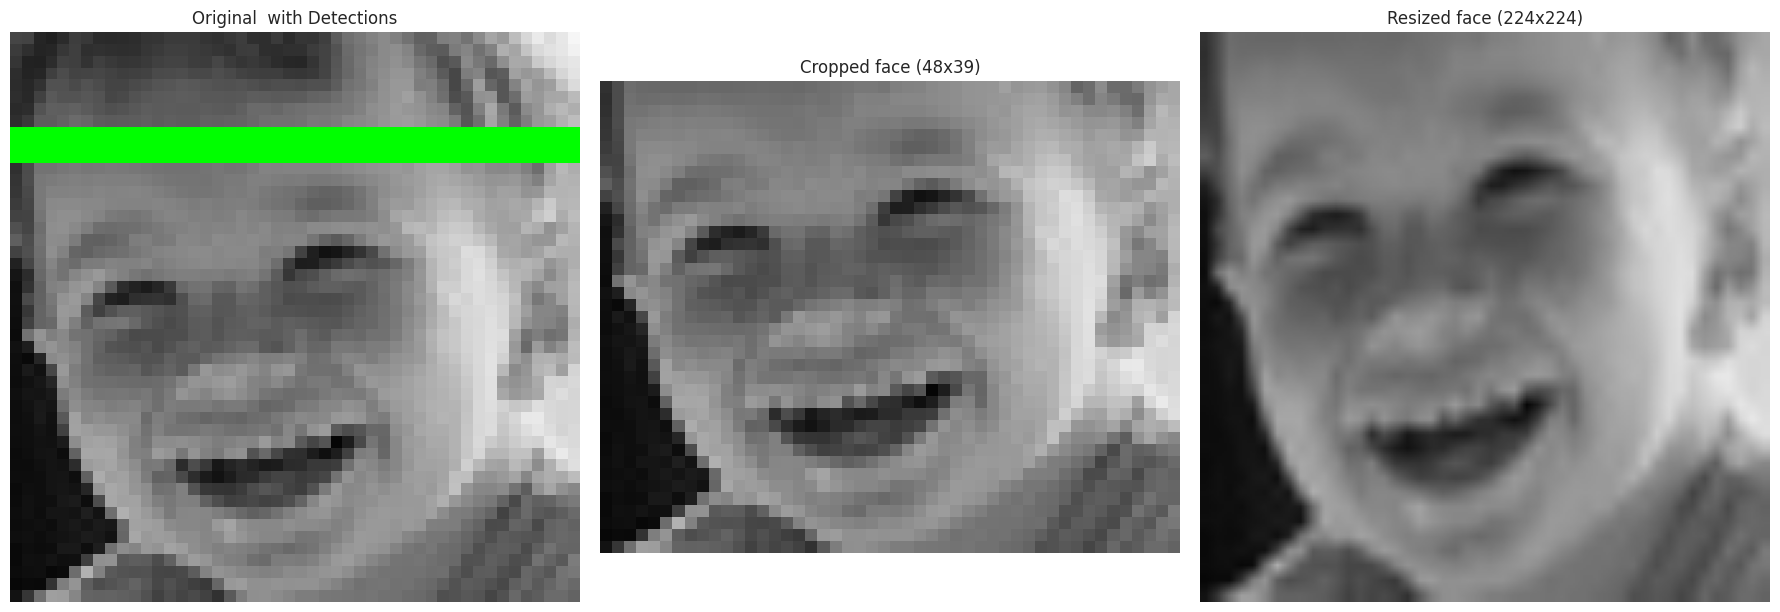

Face Detection successful
original size : (48, 48, 3)
Final size : (224, 224, 3)


In [13]:
# Testing face detection with a sample image
print("Testing face detection !!")

train_path = fer_base_path / "train"
sample_image_path = None

for emotion_folder in train_path.iterdir():
    if emotion_folder.is_dir():
        images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))
        if images:
            sample_image_path = images[0]
            emotion_name = emotion_folder.name
            break

if sample_image_path:
    print(f"Using sample: {sample_image_path.name} ({emotion_name})")

    # load and test
    sample_image = cv2.imread(str(sample_image_path))
    if sample_image is not None:
        cropped_face = detect_and_crop_face(sample_image, show_visualization=True)
        
        if cropped_face is not None:
            print(f"Face Detection successful")
            print(f"original size : {sample_image.shape}")
            print(f"Final size : {cropped_face.shape}")
        else:
            print("face detection failed!")
        
    else:
        print("could not load sample image!")

else:
    print("No sample image found")

### Facial Landmark Extraction experiment

In [14]:
# using mediapipe face Mesh
def extract_facial_landmark(face_image, show_visualization=True):
    try:
        rgb_image = cv2.cvtColor(face_image, cv2.COLOR_BGR2RGB)

        # Create face mesh instance
        with mp_face_mesh.FaceMesh(
            static_image_mode = True,
            max_num_faces = 1,
            refine_landmarks = True,
            min_detection_confidence = 0.5
        ) as face_mesh:
            
            results = face_mesh.process(rgb_image)

            if results.multi_face_landmarks:
                landmarks = []
                face_landmarks = results.multi_face_landmarks[0]

                for landmark in face_landmarks.landmark:
                    # store x, y, z coordinates
                    landmarks.extend([landmark.x, landmark.y, landmark.z])
                
                landmark_array = np.array(landmarks)

                # visualization
                if show_visualization:
                    annotated_image = face_image.copy()
                    mp_drawing.draw_landmarks(
                        image = annotated_image,
                        landmark_list = face_landmarks,
                        connections = mp_face_mesh.FACEMESH_TESSELATION,
                        landmark_drawing_spec = None,
                        connection_drawing_spec = mp_drawing_styles.get_default_face_mesh_tesselation_style()
                    )

                    # display 
                    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
                    axes[0].imshow(cv2.cvtColor(face_image, cv2.COLOR_BGR2RGB))
                    axes[0].set_title('Original Face')
                    axes[0].axis('off')

                    axes[1].imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
                    axes[1].set_title('With 478 facial landmarks')
                    axes[1].axis('off')

                    plt.tight_layout()
                    plt.show()

                    print("Landmark Statistics:")
                    print("Total landmarks: 478 and coordinates per landmark: 3(x, y, z)")
                    print(f"Total features: {len(landmark_array)}")
                    print(f"Shape: {landmark_array.shape}")
                    print(f"Sample values: {landmark_array[:9]}")  # first 3 landmarks

                return landmark_array

            else:
                if show_visualization:
                    print("No facial landmarks detected")
                return None
    
    except Exception as e:
        print(f" Error extracted landmarks: {e}")
        return None


 Using happy sample: Training_21410769.jpg


I0000 00:00:1761508297.155637    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508297.161943   11757 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508297.165246   11750 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1761508297.174386    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508297.180511   11786 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508297.181714   11765 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508297.200462   11761 inference_feedback_manager.cc:114] Feedback manager requ

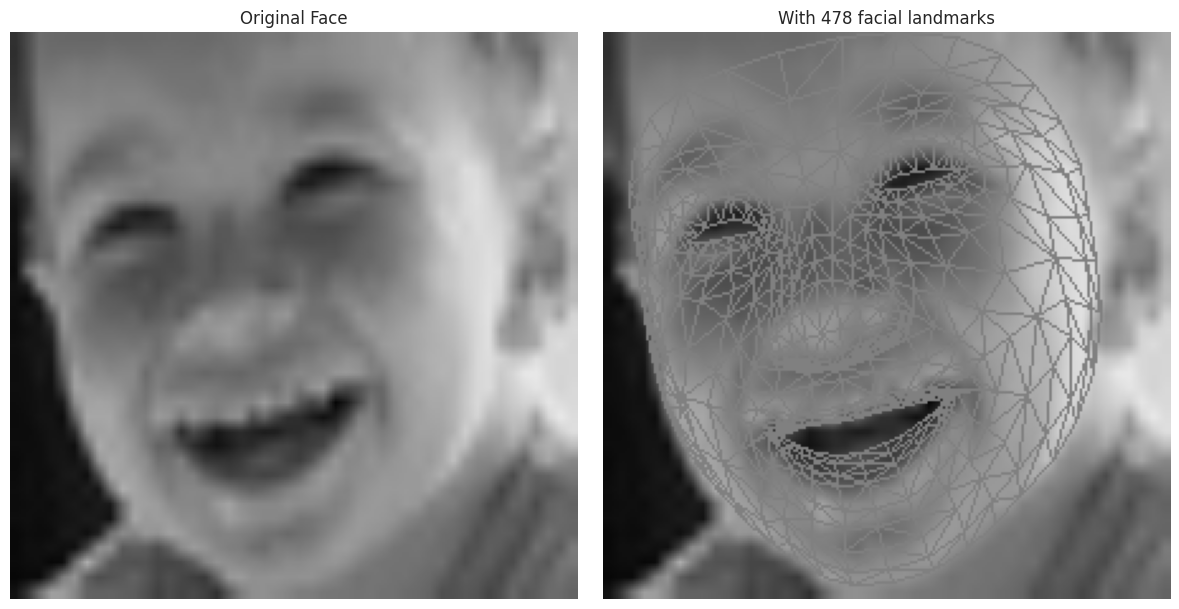

Landmark Statistics:
Total landmarks: 478 and coordinates per landmark: 3(x, y, z)
Total features: 1434
Shape: (1434,)
Sample values: [ 0.42492539  0.66254818 -0.10308881  0.39357334  0.5703944  -0.18841229
  0.41347602  0.59431958 -0.10881869]
Successfully extracted 1434 landmark coordinates.


In [15]:
# Testing landmark extraction 
train_path = fer_base_path / 'train'

happy_path = train_path / 'happy'
if happy_path.exists():
    images = list(happy_path.glob("*.jpg")) + list(happy_path.glob("*.png"))
    if images:
        sample_path = images[0]
        print(f" Using happy sample: {sample_path.name}")

        sample_image = cv2.imread(str(sample_path))
        if sample_image is not None:
            cropped_face = detect_and_crop_face(sample_image, show_visualization=False)

            if cropped_face is not None:
                landmarks = extract_facial_landmark(cropped_face, show_visualization=True)

                if landmarks is not None:
                    print(f"Successfully extracted {len(landmarks)} landmark coordinates.")
                else:
                    print("Landmark extraction failed")
            else:
                print("face detection failed")
        else:
            print("Can't load sample image.")

    else:
        print("Happy image not found")

else:
    print("Folder not found!")


### Image augmentation

In [16]:
def augment_facial_image(image):
    augmented = []

    # original image
    augmented.append(('original', image))

    # horizontal flip
    flipped = cv2.flip(image, 1)
    augmented.append(('flipped', flipped))

    # brightness adjustments
    bright = np.clip(image * 1.2, 0, 1) 
    augmented.append(('bright', bright))

    dark = np.clip(image * 0.8, 0, 1)
    augmented.append(('dark', dark))

    # Contrast adjustment
    contrast = np.clip((image - 0.5) * 1.3 + 0.5, 0, 1)
    augmented.append(('contrast', contrast))

    # Slight rotation
    h, w = image.shape[:2]
    center = (w // 2, h//2)

    # Rotate +5 degree
    M1 = cv2.getRotationMatrix2D(center, 5, 1.0)
    rotated_pos = cv2.warpAffine(image, M1, (w, h))
    augmented.append(('rotated_+5', rotated_pos))

    # Rotate -5 degree
    M2 = cv2.getRotationMatrix2D(center, -5, 1.0)
    rotated_neg = cv2.warpAffine(image, M2, (w, h))
    augmented.append(('rotated_-5', rotated_neg))

    # Gaussian noise
    noise = np.random.normal(0, 0.02, image.shape)
    noisy = np.clip(image + noise, 0, 1)
    augmented.append(('noisy', noisy))

    # Gaussian blur
    blurred = cv2.GaussianBlur(image, (3, 3), 0)
    augmented.append(('blurred', blurred))

    return augmented

Using angry sample: Training_36072885.jpg


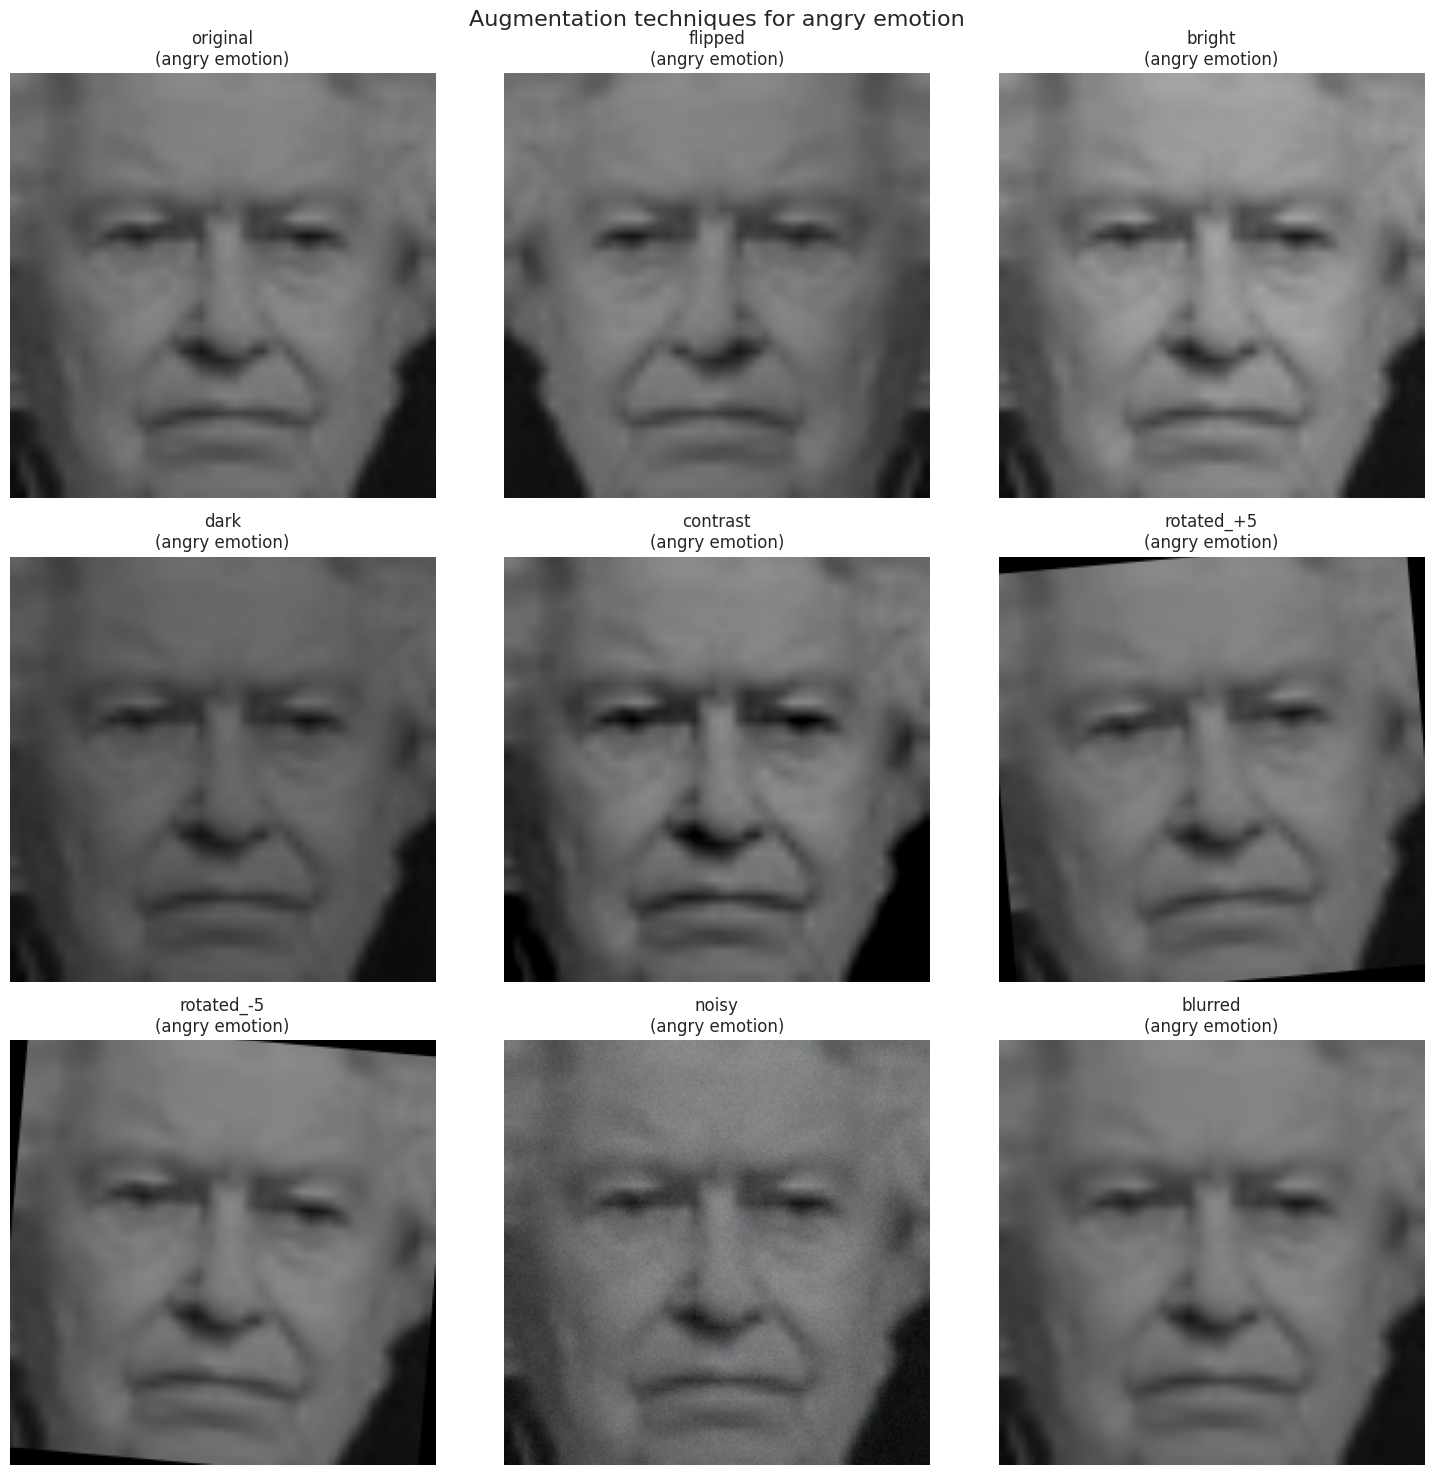

Generated 9 augmented versions
Augmentation types: ['original', 'flipped', 'bright', 'dark', 'contrast', 'rotated_+5', 'rotated_-5', 'noisy', 'blurred']
Using happy sample: Training_21410769.jpg
Generated 9 augmented version


In [17]:
# Testing augmentation
train_path = fer_base_path / "train"
angry_path = train_path / "angry"

images = list(angry_path.glob("*.jpg")) + list(angry_path.glob("*.png"))
sample_path = images[0]
print(f"Using angry sample: {sample_path.name}")

# Load and preprocess
image = cv2.imread(str(sample_path))
if image is not None:
    image_resized = cv2.resize(image, config.IMAGE_SIZE)
    image_normalized = image_resized.astype(np.float32) / 255.0

    # Apply augmentations
    augmented_images = augment_facial_image(image_normalized)

    # visualization of augmentations
    n_augmentation = len(augmented_images)
    cols = 3
    rows = (n_augmentation + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize = (15, rows * 5))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    

    for idx, (aug_name, aug_image) in enumerate(augmented_images):
        axes[idx].imshow(cv2.cvtColor((aug_image * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[idx].set_title(f"{aug_name}\n(angry emotion)")
        axes[idx].axis('off')

    plt.suptitle('Augmentation techniques for angry emotion', fontsize=16)
    plt.tight_layout()
    plt.show()

    print(f"Generated {len(augmented_images)} augmented versions")
    print(f"Augmentation types: {[name for name, _ in augmented_images]}")

else:
    print("Could not load image")

# Try any available emotion
for emotion_folder in train_path.iterdir():
    if emotion_folder.is_dir():
        images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))
        if images:
            sample_path = images[0]
            emotion_name = emotion_folder.name
            print(f"Using {emotion_name} sample: {sample_path.name}")

            image = cv2.imread(str(sample_path))
            image_resized = cv2.resize(image, config.IMAGE_SIZE)
            image_normalized = image_resized.astype(np.float32) / 255.0
            augmented_images = augment_facial_image(image_normalized)

            print(f"Generated {len(augmented_images)} augmented version")

            break


### Single image processing pipeline

In [18]:
def preprocess_single_facial_image(image_path, emotion_label, show_steps=True):
    try:
        # loading image
        if isinstance(image_path, (str, Path)):
            image = cv2.imread(str(image_path))
            
        else:
            image = image_path.copy()

        image_resized = cv2.resize(image, config.IMAGE_SIZE)

        image_normalized = image_resized.astype(np.float32) / 255.0

        landmarks = extract_facial_landmark(image_resized, show_visualization=False)

        # Applying augmentation
        if config.ENABLE_AUGMENTATION:
            augmented = augment_facial_image(image_normalized)
        else:
            augmented = [('original', image_normalized)]

        # Visualization
        fig, axes = plt.subplots(1, 4, figsize = (16, 4))
        axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Original\n({image.shape[0]} X {image.shape[1]})")
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'Resized\n({config.IMAGE_SIZE[0]} x {config.IMAGE_SIZE[1]})')
        axes[1].axis('off')

        axes[2].imshow(cv2.cvtColor((image_normalized * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[2].set_title('Normalized (0-1 range)')
        axes[2].axis('off')

        axes[3].text(0.1, 0.5, f"Emotion: {emotion_label}\n\n"
                                f"Landmarks: {len(landmarks) if landmarks is not None else 0}\n\n"
                                f"Augmentations: {len(augmented)}\n\n"
                                f"Final shape: {image_normalized.shape}",
                                fontsize = 12, verticalalignment = 'center')
        axes[3].axis('off')

        plt.suptitle(f"Processing pipeline for {emotion_label.upper()} emotion", fontsize=14)
        plt.tight_layout()
        plt.show()

        return {
            'image': image_normalized,
            'landmarks': landmarks,
            'emotion': emotion_label,
            'augmented': augmented,
            'image_shape': image_normalized.shape,
            'has_landmarks': landmarks is not None
        }
    except Exception as e:
        print(f"Error in preprocessing: {e}")
        return None

Testing with: Training_21410769.jpg (happy)


I0000 00:00:1761508298.062394    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508298.069053   11821 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508298.071679   11804 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508298.086853   11793 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


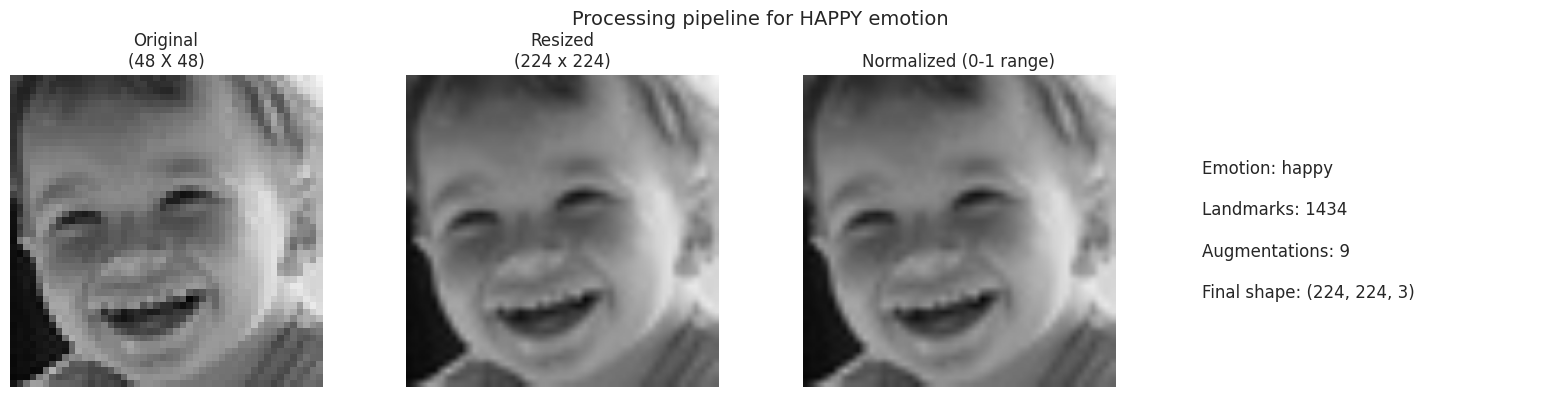

Preprocessing successful!
Results:
 Emotin: happy
 Image shape: (224, 224, 3)
 Landmarks: 1434
 Augmentations: 9


In [19]:
# Testing pipeline
train_path = fer_base_path / "train"
surprise_path = train_path / "surprise"

sample_path = None
emotion_name = None

for emotin_folder in train_path.iterdir():
    if emotion_folder.is_dir():
        images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))
        if images:
            sample_path = images[0]
            emotion_name = emotion_folder.name
            break

if sample_path and emotion_name:
    print(f"Testing with: {sample_path.name} ({emotion_name})")
    processed = preprocess_single_facial_image(sample_path, emotion_name, show_steps=True)

    print(f"Preprocessing successful!")
    print("Results:")
    print(f" Emotin: {processed['emotion']}")
    print(f" Image shape: {processed['image'].shape}")
    print(f" Landmarks: {len(processed['landmarks']) if processed['landmarks'] is not None else 'None'}")
    print(f" Augmentations: {len(processed['augmented'])}")


else:
    print("No sample images found")

### Batch Processing experiment

In [20]:
# processing multiple folders from different emotions
def batch_process_folders(sample_size=5):
    train_path = fer_base_path / "train"

    # Get samples from each emotion
    emotion_samples = {}
    for emotion_folder in train_path.iterdir():
        if emotion_folder.is_dir() and emotion_folder.name in fer_emotions.values():
            images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))
            if images:
                sample_count = min(sample_size, len(images))
                selected_images = np.random.choice(images, sample_count, replace=False)
                emotion_samples[emotion_folder.name] = selected_images

    print("Selected samples are:")
    for emotion, samples in emotion_samples.items():
        print(f" {emotion}: {len(samples)} samples")

    # processing all samples
    all_processed = []

    for emotion, sample_paths in emotion_samples.items():
        for idx, img_path in enumerate(tqdm(sample_paths, desc=emotion)):
            try:
                processed = preprocess_single_facial_image(img_path, emotion, show_steps=False)
                if processed:
                    processed['emotion_code'] = emotion_to_code.get(emotion, -1)
                    processed['split'] = 'train'
                    processed['original_path'] = str(img_path)
                    all_processed.append(processed)

            except Exception as e:
                print(f"Error processing {img_path.name}: {e}")
                continue

        processed_count = len([p for p in all_processed if p['emotion'] == emotion])
        print(f"Processed {processed_count} {emotion} samples")

    return all_processed



Selected samples are:
 happy: 3 samples
 disgust: 3 samples
 angry: 3 samples
 surprise: 3 samples
 neutral: 3 samples
 fear: 3 samples
 sad: 3 samples


happy:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761508298.308896    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508298.313531   11851 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508298.316269   11824 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508298.329135   11849 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


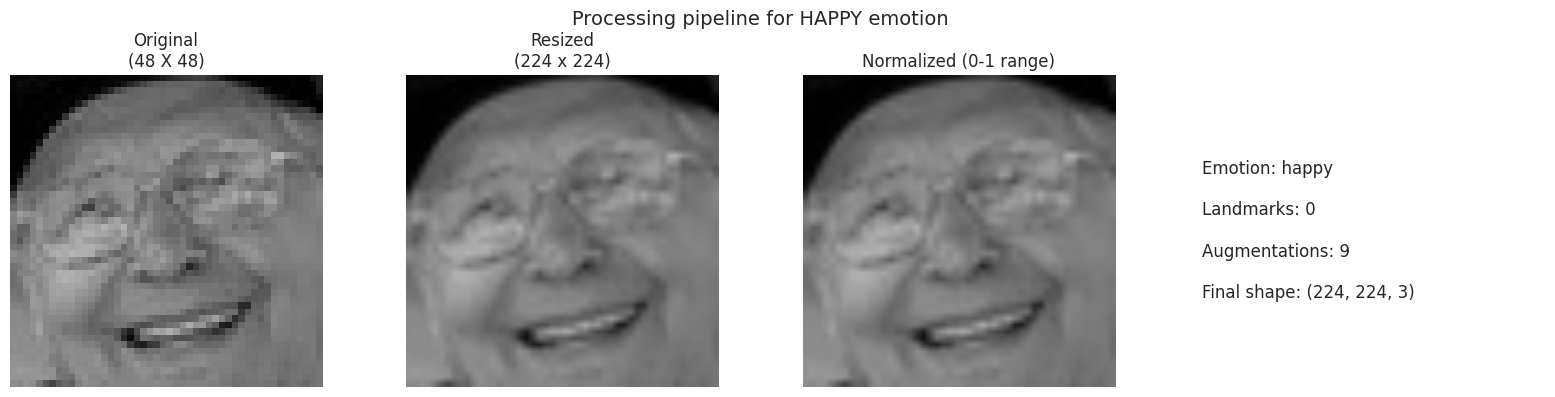

happy:  33%|███▎      | 1/3 [00:00<00:00,  6.71it/s]I0000 00:00:1761508298.459633    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508298.465192   11880 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508298.468935   11852 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508298.482920   11853 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


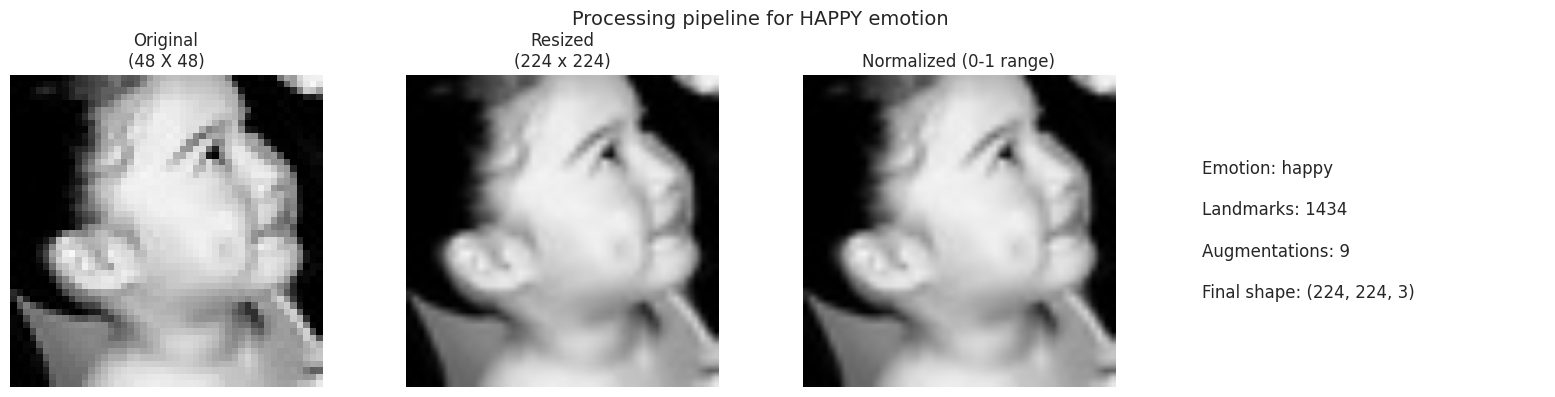

happy:  67%|██████▋   | 2/3 [00:00<00:00,  6.54it/s]I0000 00:00:1761508298.615132    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508298.620596   11909 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508298.625052   11895 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508298.638934   11906 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


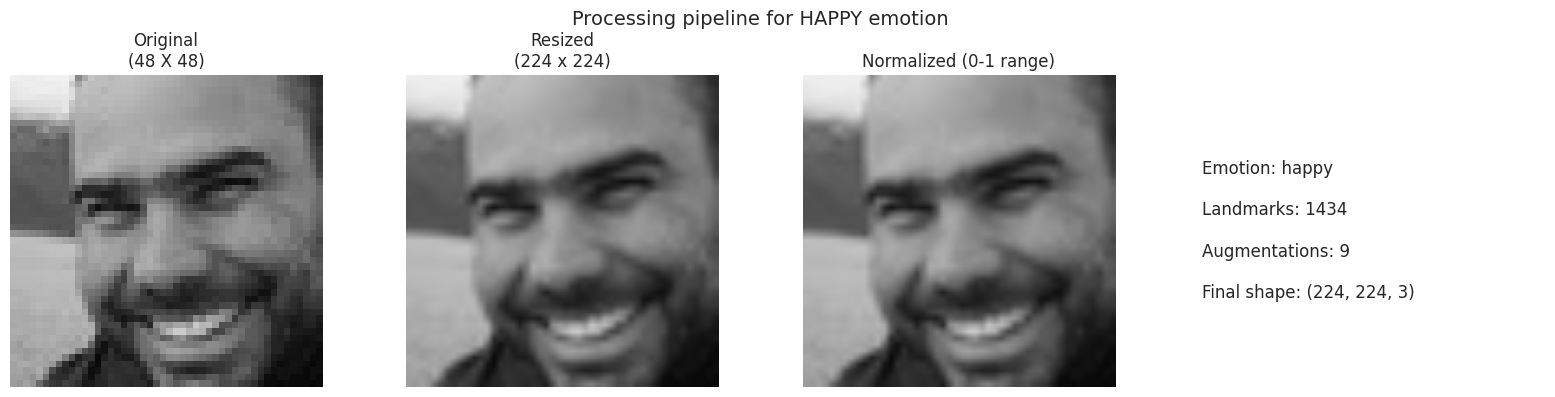

happy: 100%|██████████| 3/3 [00:00<00:00,  5.18it/s]


Processed 3 happy samples


disgust:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761508298.890441    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508298.894512   11938 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508298.895705   11911 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508298.910545   11910 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


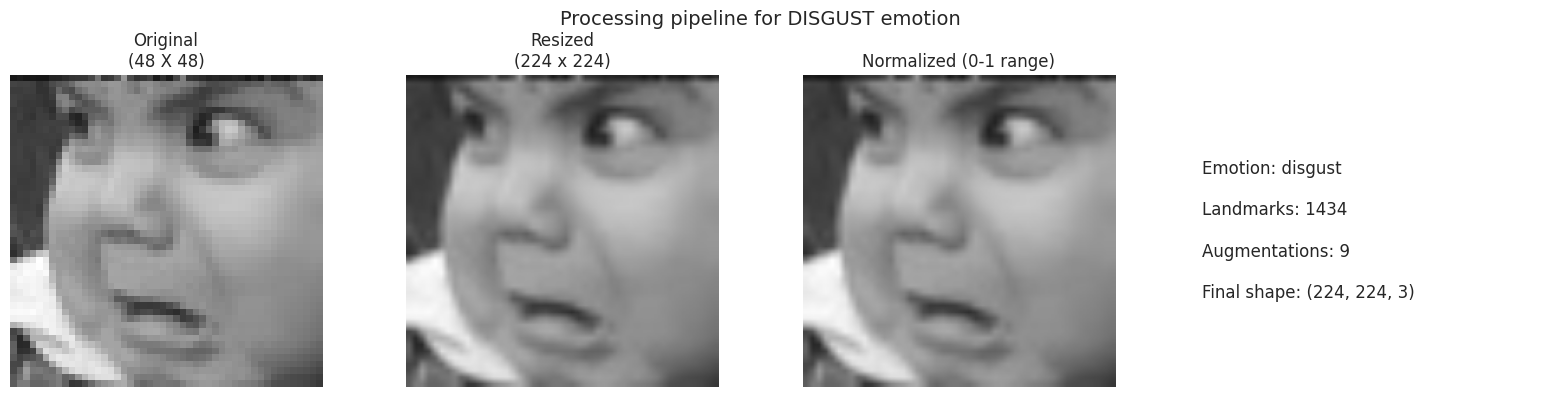

disgust:  33%|███▎      | 1/3 [00:00<00:00,  6.33it/s]I0000 00:00:1761508299.048826    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508299.053910   11967 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508299.056946   11945 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508299.065264   11947 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


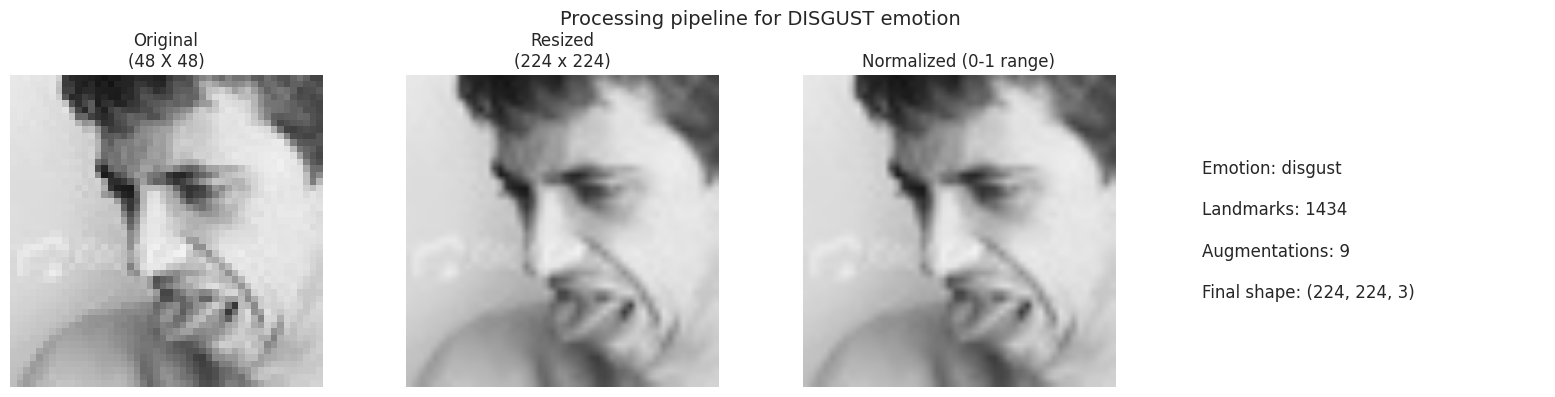

disgust:  67%|██████▋   | 2/3 [00:00<00:00,  6.52it/s]I0000 00:00:1761508299.199751    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508299.204934   11996 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508299.207548   11979 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508299.215290   11995 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


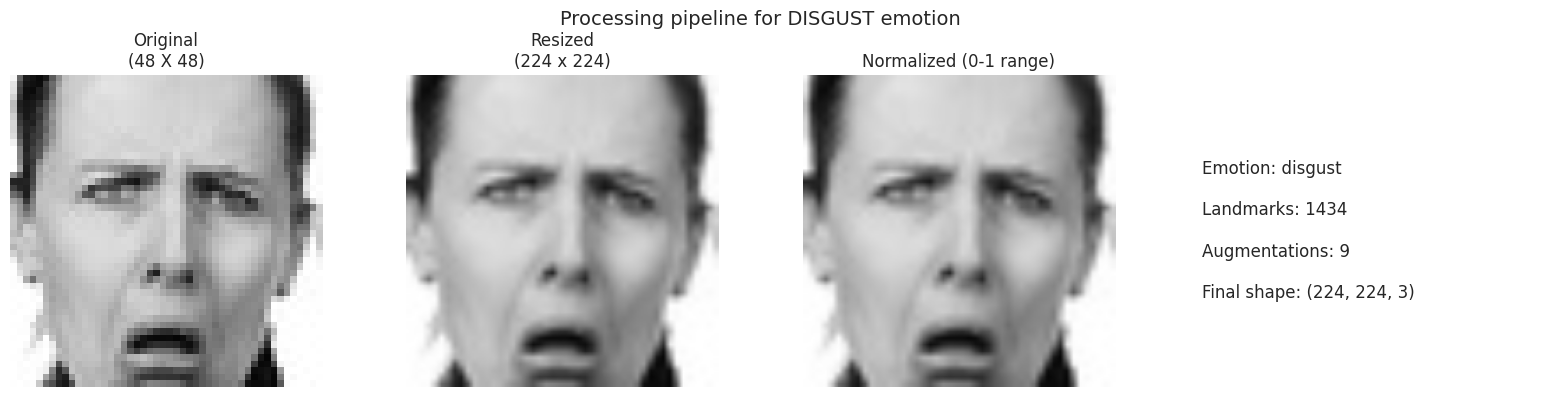

disgust: 100%|██████████| 3/3 [00:00<00:00,  6.55it/s]


Processed 3 disgust samples


angry:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761508299.349958    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508299.355214   12025 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508299.357579   12001 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508299.369108   12023 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


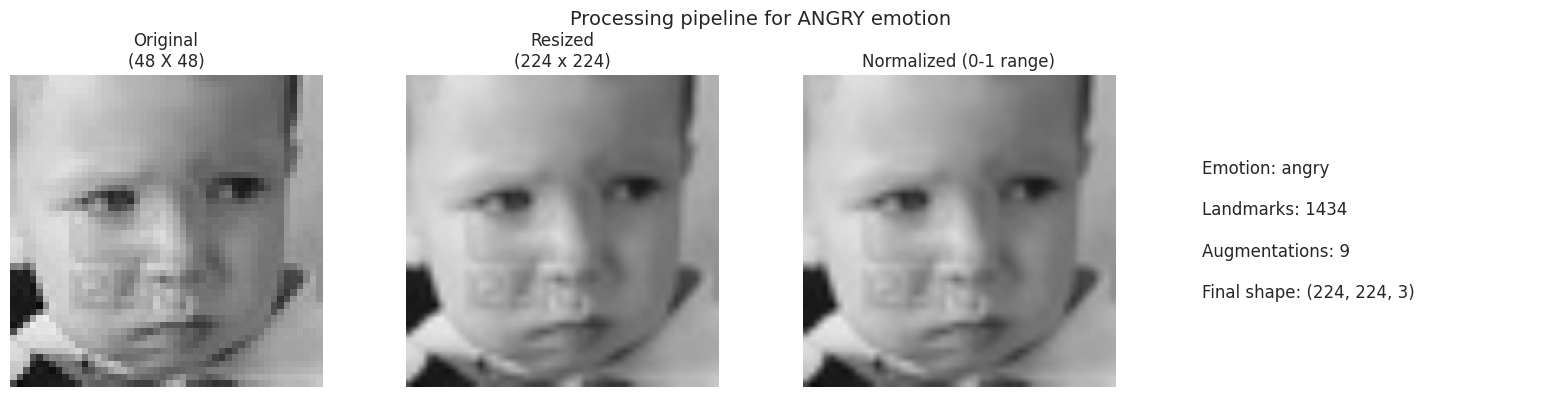

angry:  33%|███▎      | 1/3 [00:00<00:00,  6.39it/s]I0000 00:00:1761508299.507519    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508299.512358   12054 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508299.514222   12029 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508299.527889   12026 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


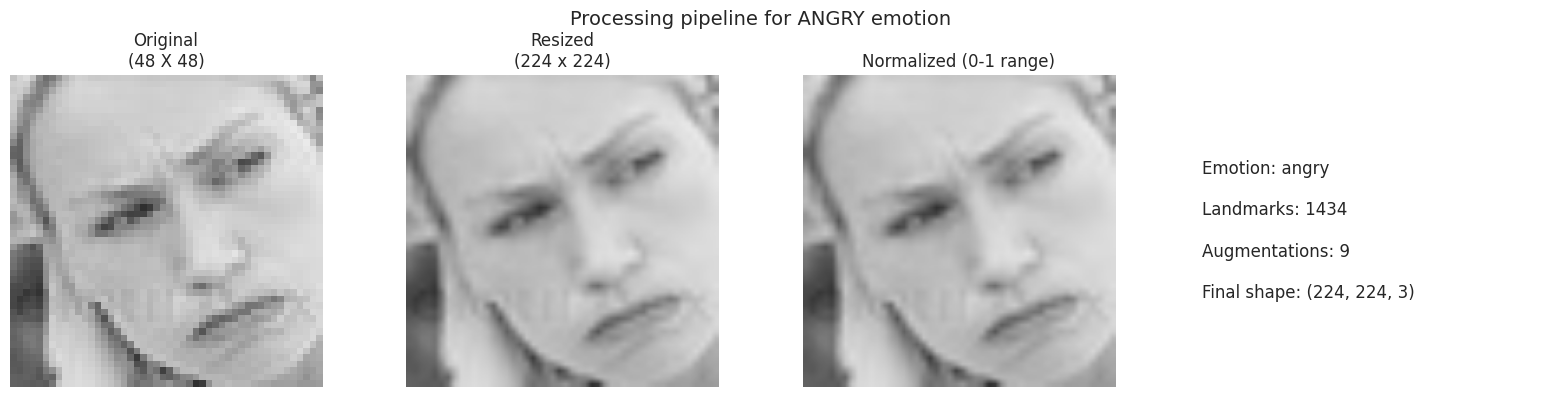

angry:  67%|██████▋   | 2/3 [00:00<00:00,  6.45it/s]I0000 00:00:1761508299.660170    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508299.665118   12083 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508299.668415   12056 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508299.674282   12078 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


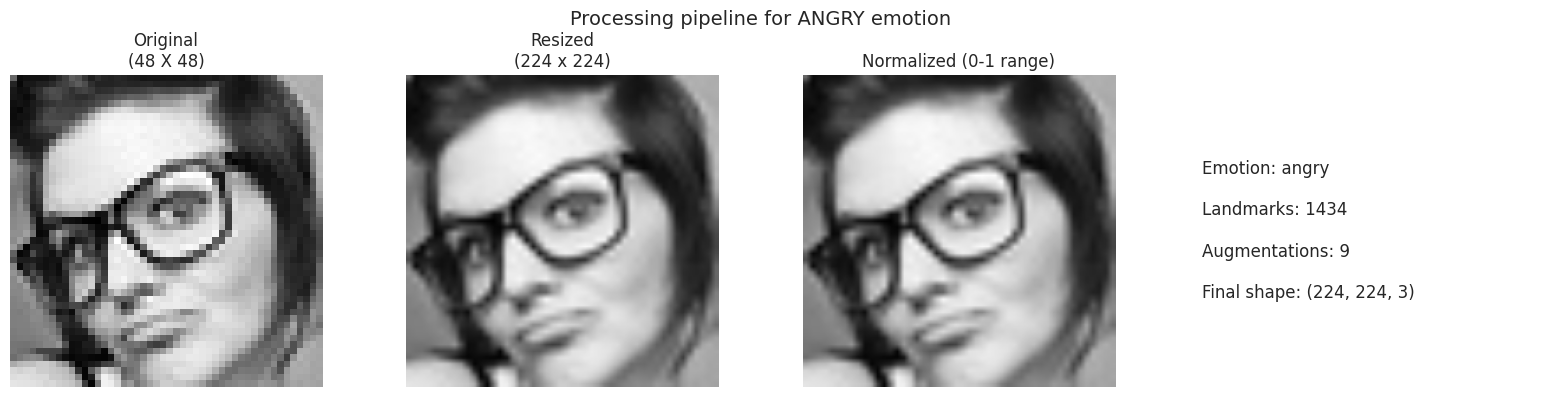

angry: 100%|██████████| 3/3 [00:00<00:00,  6.50it/s]


Processed 3 angry samples


surprise:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761508299.813347    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508299.819900   12112 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508299.823759   12088 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508299.835344   12109 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


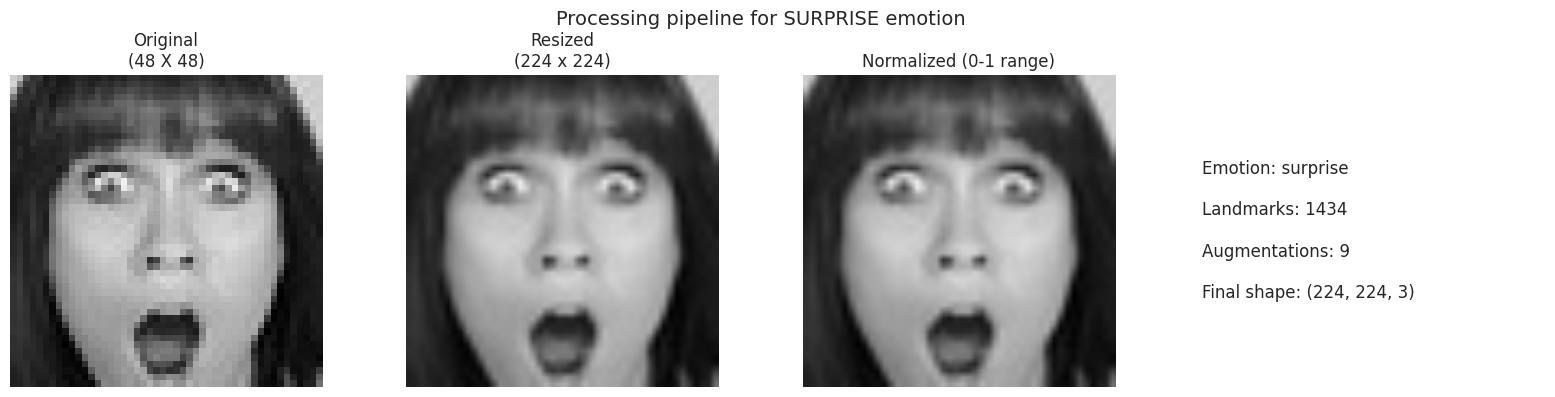

surprise:  33%|███▎      | 1/3 [00:00<00:00,  6.28it/s]I0000 00:00:1761508299.974053    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508299.980295   12144 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508299.984656   12122 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508300.000172   12121 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


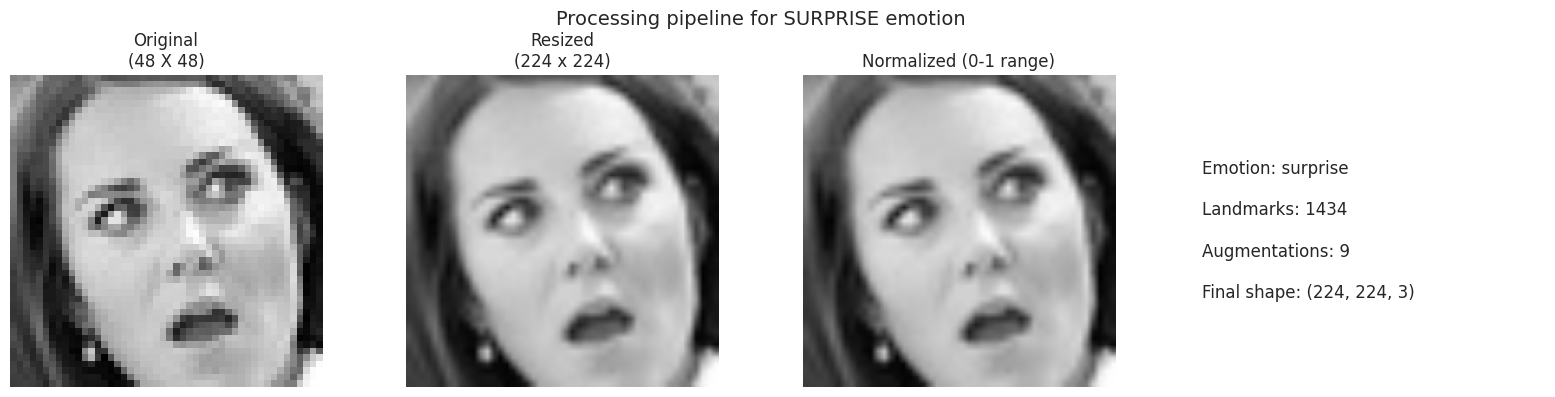

surprise:  67%|██████▋   | 2/3 [00:00<00:00,  6.15it/s]I0000 00:00:1761508300.137643    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508300.142924   12176 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508300.144308   12152 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508300.160727   12151 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


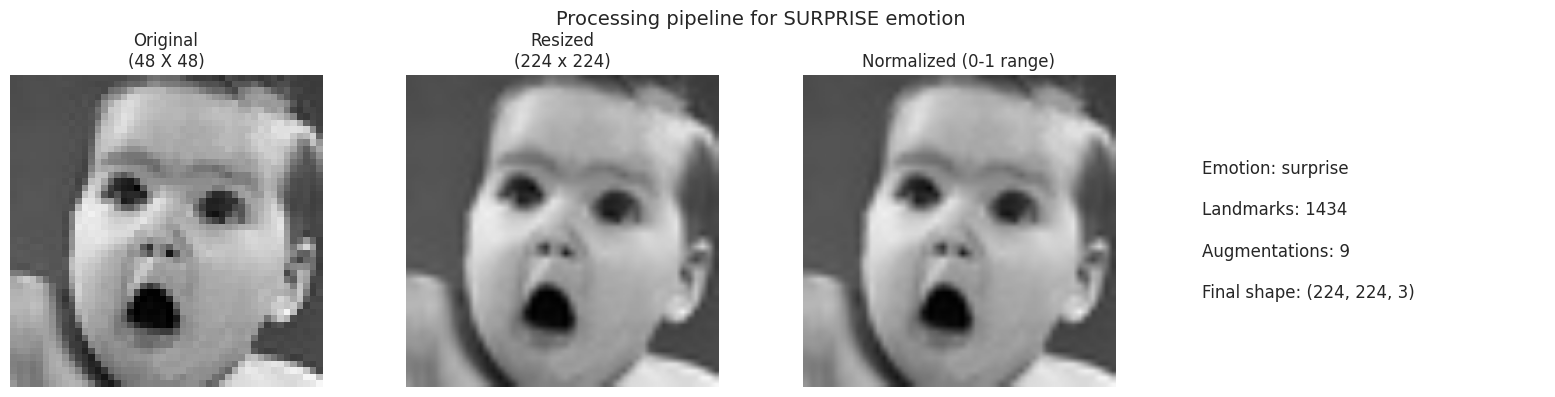

surprise: 100%|██████████| 3/3 [00:00<00:00,  6.21it/s]


Processed 3 surprise samples


neutral:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761508300.297991    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508300.303069   12205 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508300.305816   12180 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508300.322348   12177 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


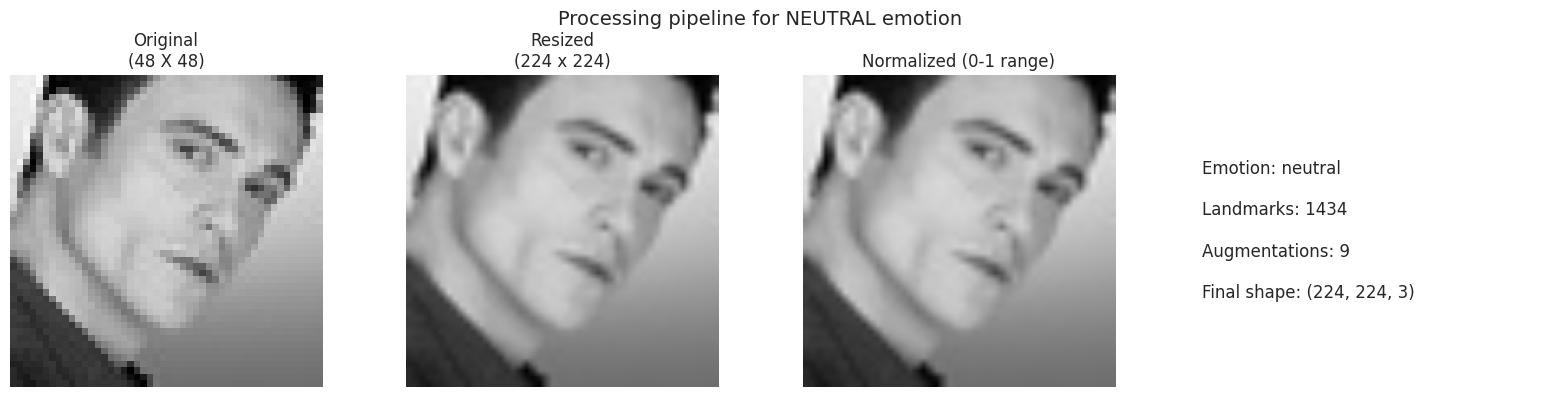

neutral:  33%|███▎      | 1/3 [00:00<00:00,  6.21it/s]I0000 00:00:1761508300.458165    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508300.463562   12234 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508300.464890   12214 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508300.478746   12208 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


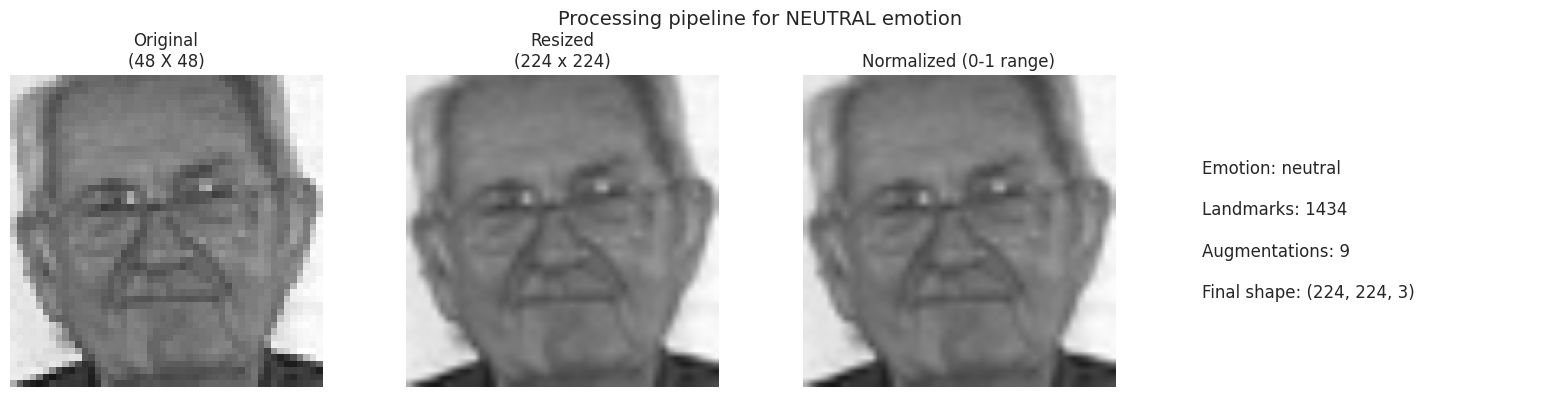

neutral:  67%|██████▋   | 2/3 [00:00<00:00,  6.22it/s]I0000 00:00:1761508300.619578    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508300.624749   12263 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508300.626112   12236 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508300.640451   12235 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


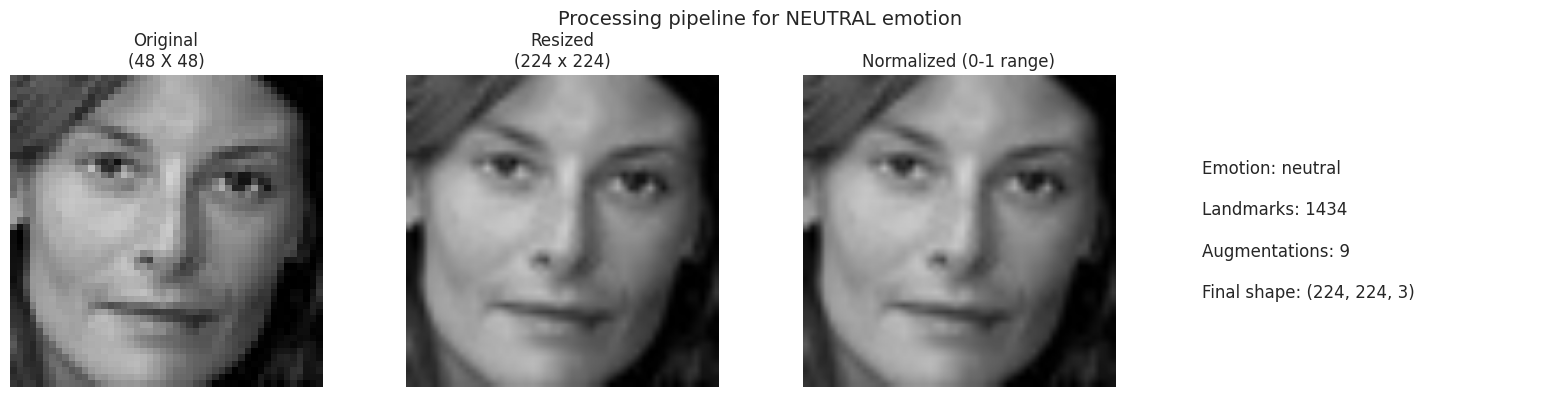

neutral: 100%|██████████| 3/3 [00:00<00:00,  6.22it/s]


Processed 3 neutral samples


fear:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761508300.780468    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508300.785933   12292 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508300.787637   12267 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508300.802615   12287 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


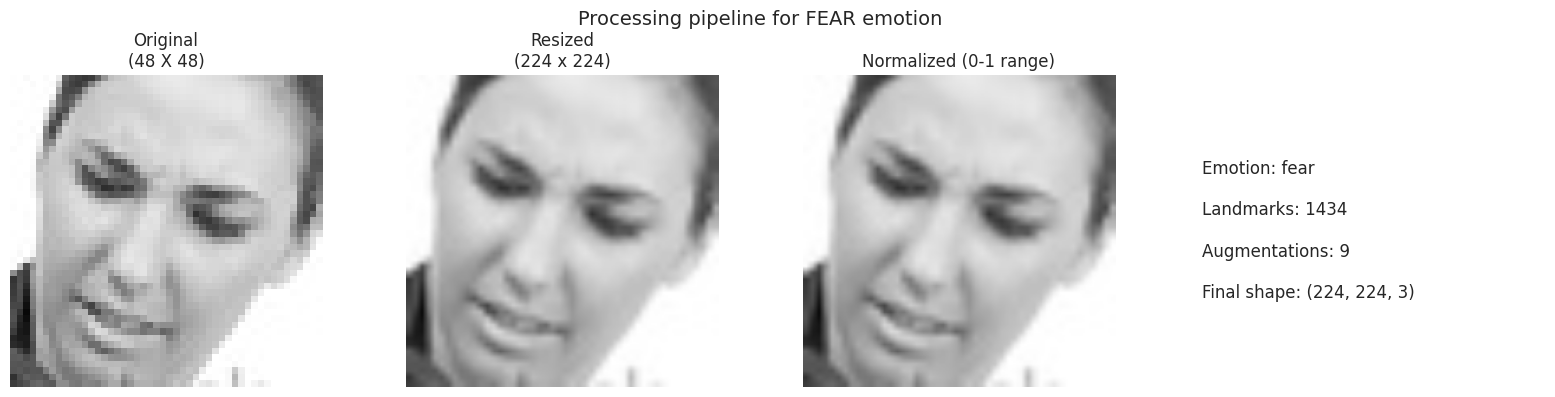

fear:  33%|███▎      | 1/3 [00:00<00:00,  6.45it/s]I0000 00:00:1761508300.935900    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508300.940789   12321 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508300.941970   12294 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508300.960052   12293 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


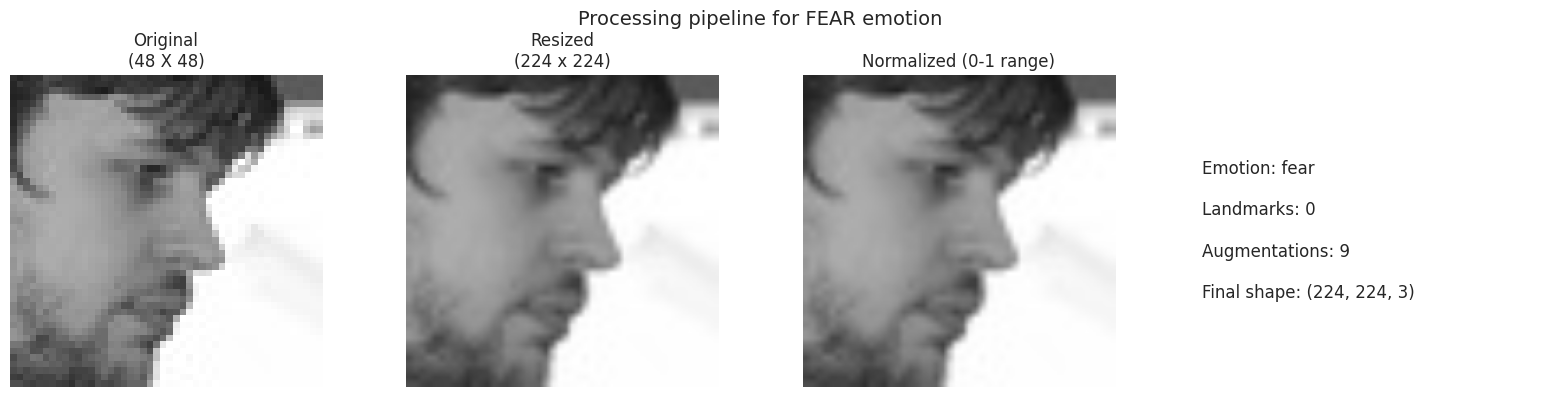

fear:  67%|██████▋   | 2/3 [00:00<00:00,  4.16it/s]I0000 00:00:1761508301.239014    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508301.243204   12350 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508301.244434   12322 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508301.252025   12348 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


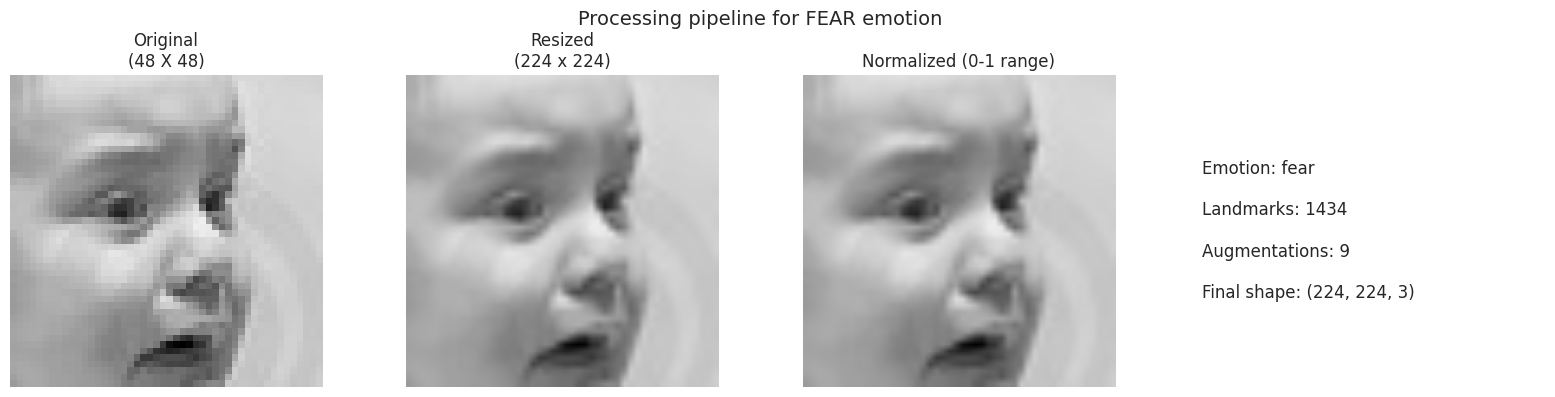

fear: 100%|██████████| 3/3 [00:00<00:00,  4.99it/s]


Processed 3 fear samples


sad:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761508301.384039    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508301.388348   12379 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508301.389665   12353 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508301.406842   12351 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


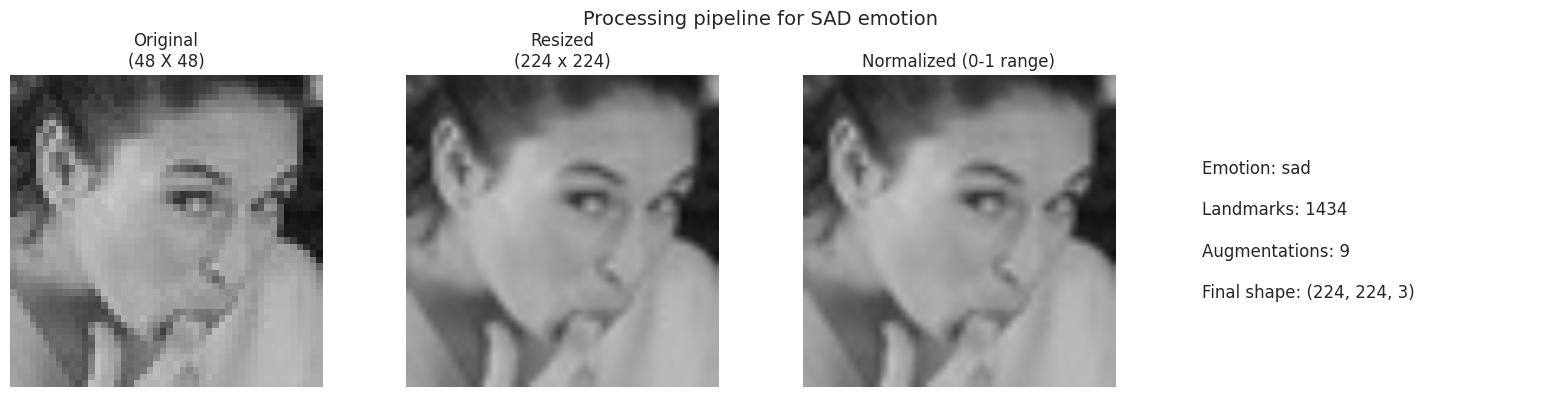

sad:  33%|███▎      | 1/3 [00:00<00:00,  6.28it/s]I0000 00:00:1761508301.543831    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508301.547926   12408 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508301.549348   12392 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508301.560330   12405 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


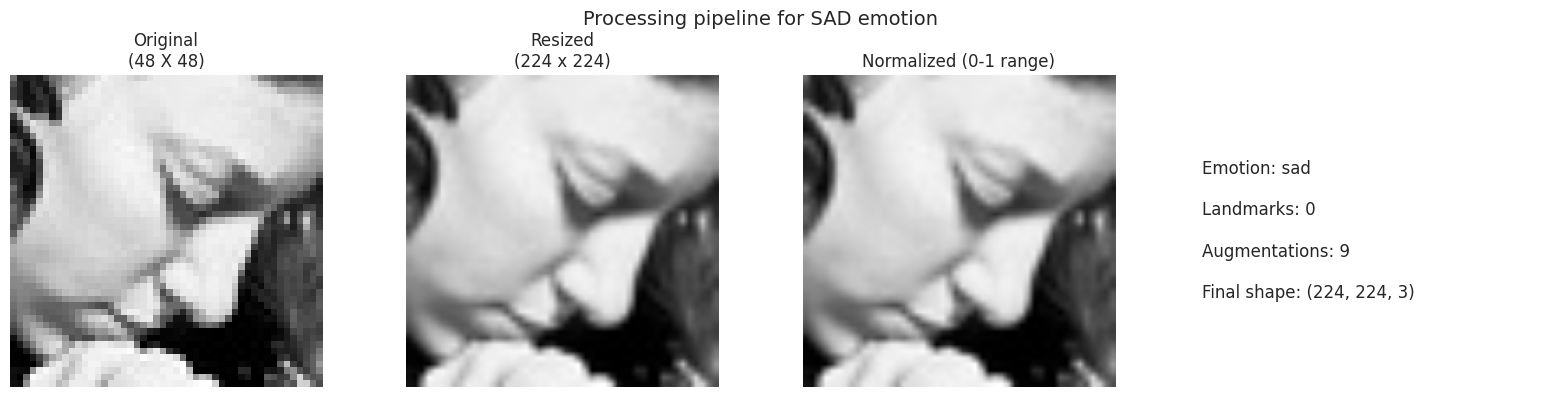

sad:  67%|██████▋   | 2/3 [00:00<00:00,  6.53it/s]I0000 00:00:1761508301.692482    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761508301.696546   12437 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761508301.697760   12415 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761508301.705915   12435 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


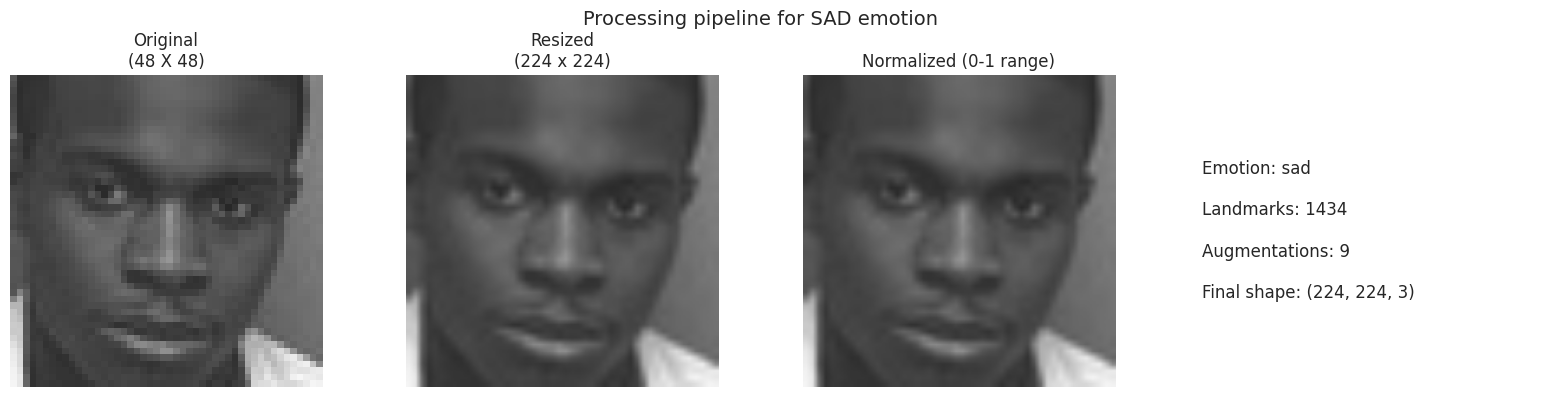

sad: 100%|██████████| 3/3 [00:00<00:00,  6.48it/s]

Processed 3 sad samples
Batch Processing complete
Total processed: 21 samples
 Distribution: {'happy': 3, 'disgust': 3, 'angry': 3, 'surprise': 3, 'neutral': 3, 'fear': 3, 'sad': 3}


In [21]:
# run batch processing
batch_processed = batch_process_folders(sample_size=3)

print("Batch Processing complete")
print(f"Total processed: {len(batch_processed)} samples")

# emotion_distribution
emotion_dist = {}
for item in batch_processed:
    emotion = item['emotion']
    emotion_dist[emotion] = emotion_dist.get(emotion, 0) + 1

print(f" Distribution: {emotion_dist}")

# Storing the later use
BATCH_PROCESSED_DATA = batch_processed

### Feature visualization & analysis

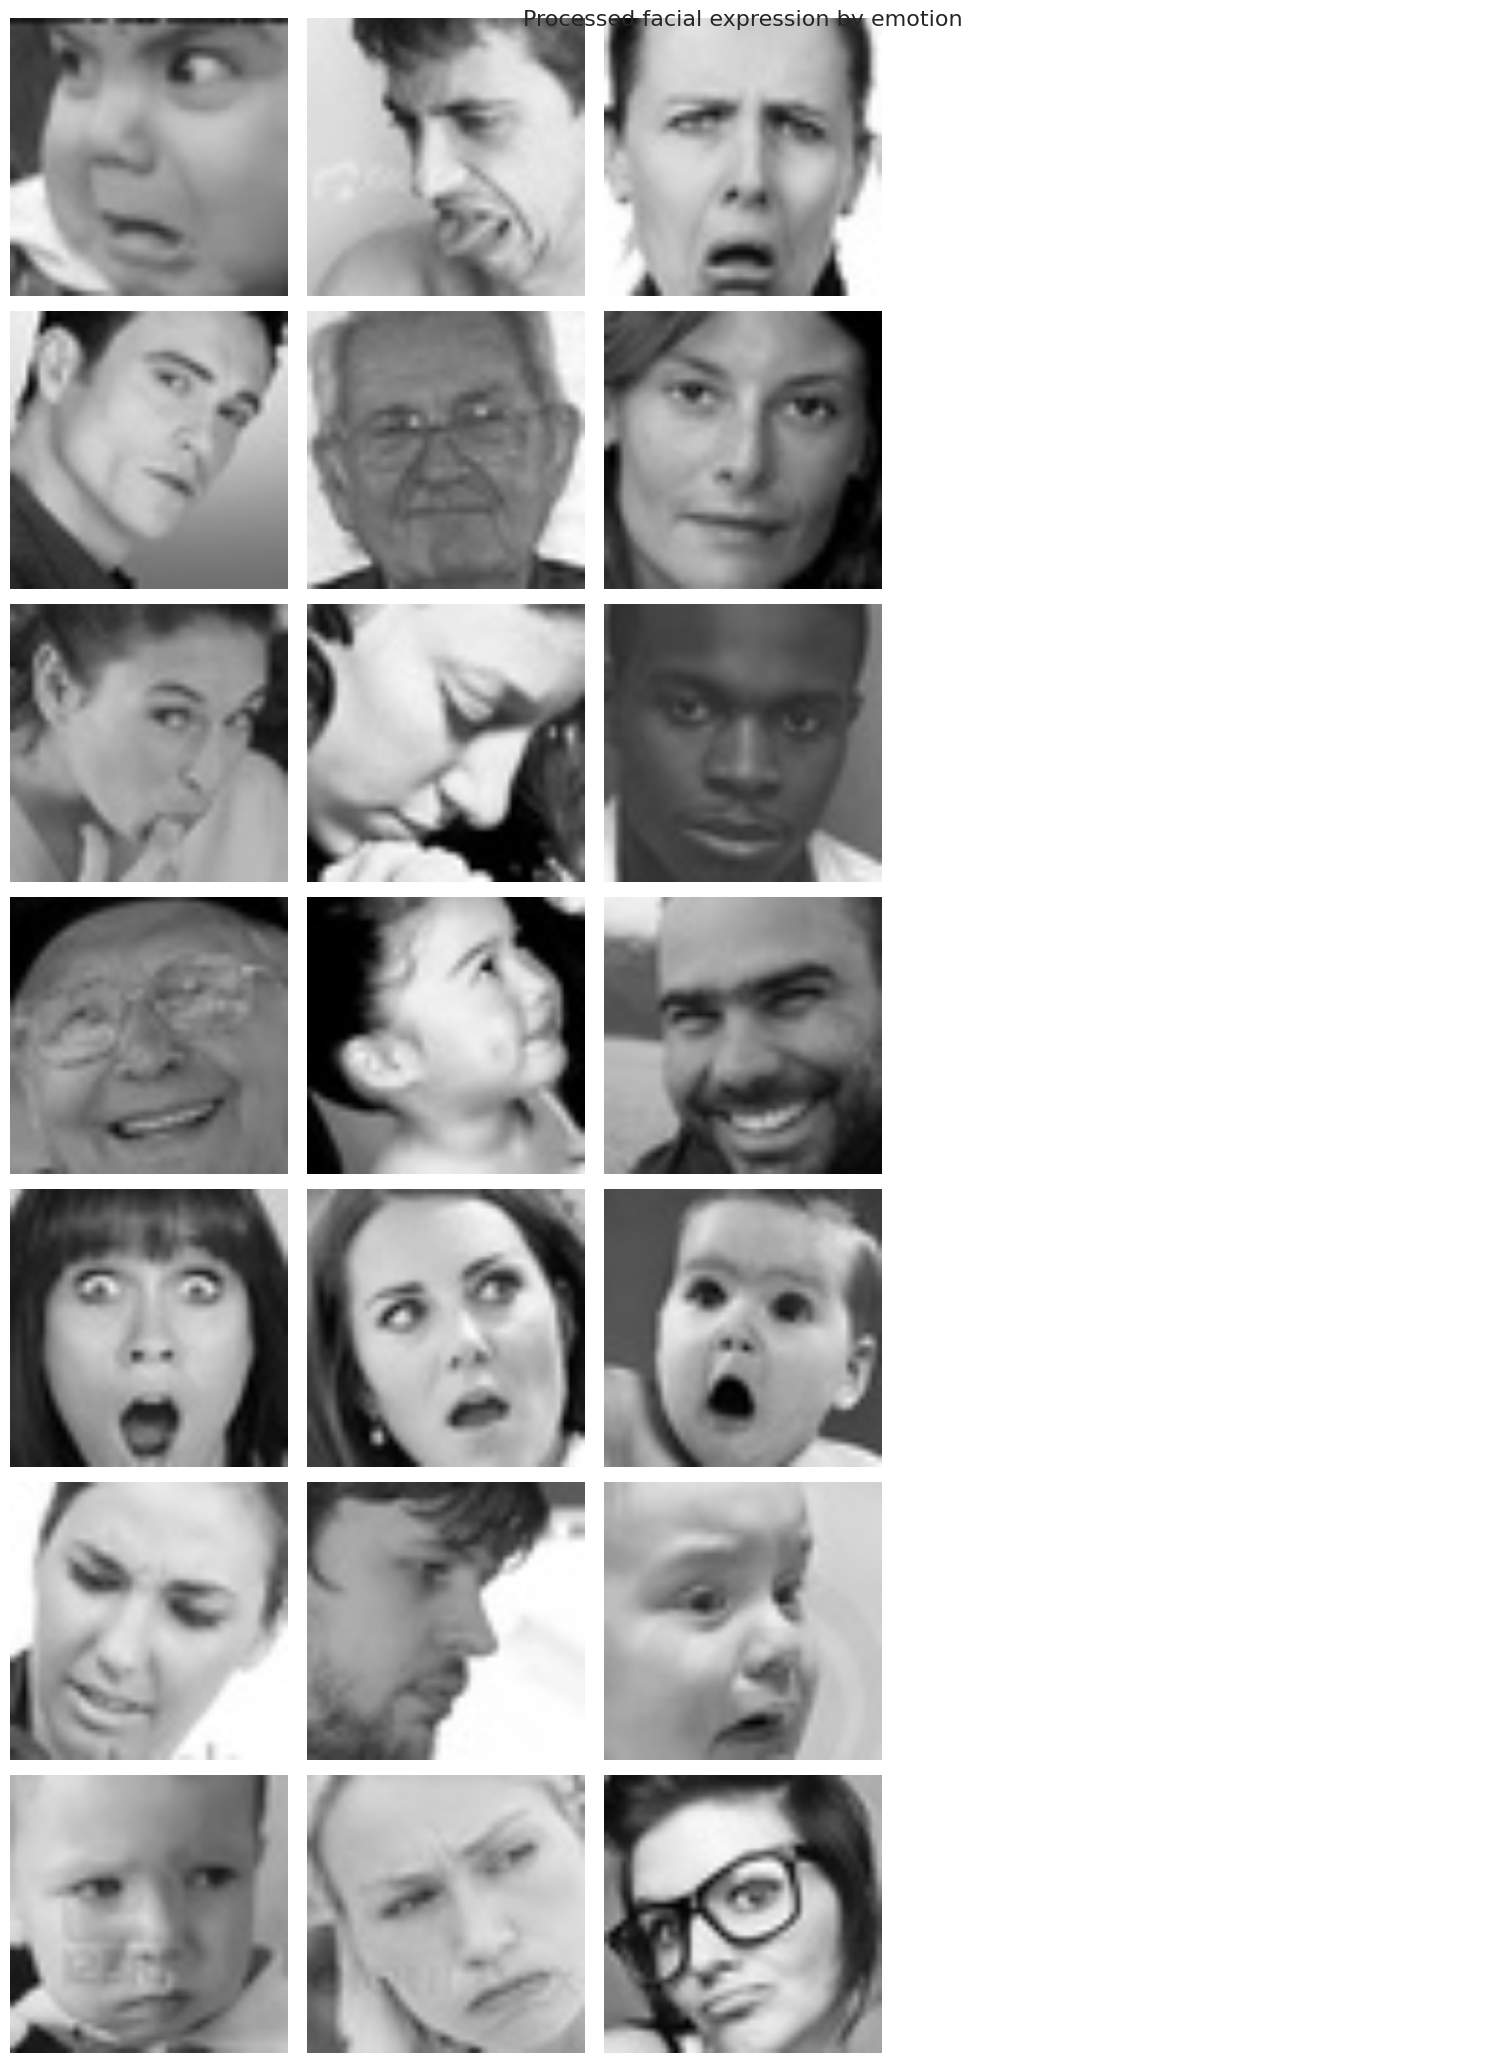

Landmark Extraction Statistics:
 With landmarks: 18
 Without landmarks: 3
 Success rate: 85.7%
 Total augmentations: 189
 Average per image: 9.0


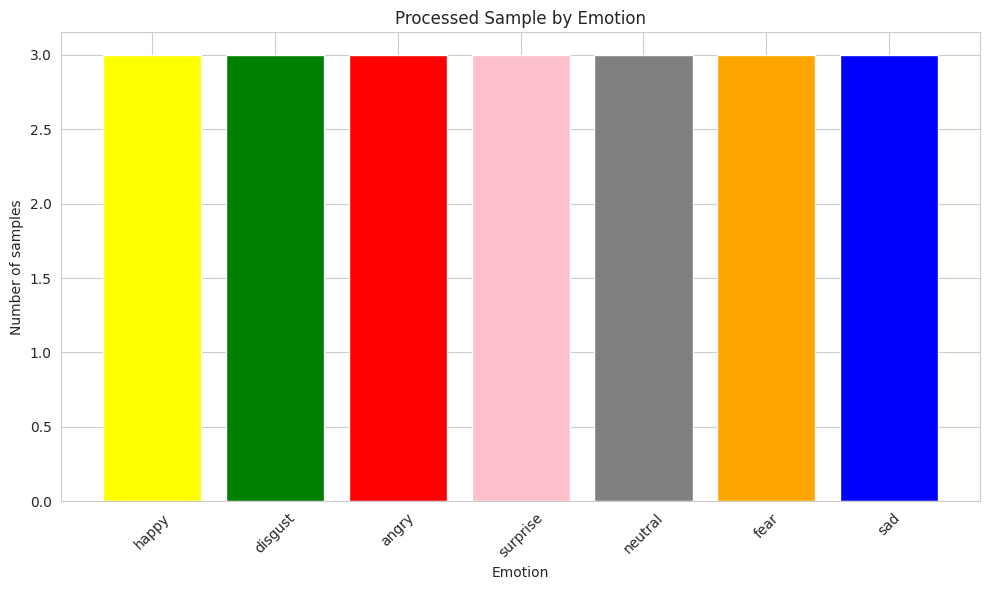

In [23]:
available_emotions = list(set(item['emotion'] for item in BATCH_PROCESSED_DATA))

fig, axes = plt.subplots(len(available_emotions), 5, figsize=(15, len(available_emotions) * 3))

# Handling single row cases
if len(available_emotions) == 1:
    axes = [axes]

for row_idx, emotion in enumerate(available_emotions):
    emotion_samples = [p for p in BATCH_PROCESSED_DATA if p['emotion'] == emotion]

    for col_idx in range(5):
        if col_idx < len(emotion_samples):
            img = emotion_samples[col_idx]['image']
            axes[row_idx][col_idx].imshow(cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2RGB))
            axes[row_idx][col_idx].axis('off')

            if col_idx == 0:
                axes[row_idx][col_idx].set_ylabel(emotion, fontsize=12, rotation=0, ha='right', va='center')
            
        else:
            axes[row_idx][col_idx].axis('off')

plt.suptitle('Processed facial expression by emotion', fontsize=16)
plt.tight_layout()
plt.show()

# Analyze landmark availability
landmark_stats = {
    'with_landmarks': 0,
    'without_landmarks': 0
}

for sample in BATCH_PROCESSED_DATA:
    if sample['landmarks'] is not None:
        landmark_stats['with_landmarks'] += 1
    else:
        landmark_stats['without_landmarks'] += 1

print(f"Landmark Extraction Statistics:")
print(f" With landmarks: {landmark_stats['with_landmarks']}")
print(f" Without landmarks: {landmark_stats['without_landmarks']}")
print(f" Success rate: {landmark_stats['with_landmarks']/len(BATCH_PROCESSED_DATA)*100:.1f}%")


# Augmentation statistics
total_augmentations = sum(len(sample['augmented']) for sample in BATCH_PROCESSED_DATA)
avg_augmentations = total_augmentations / len(BATCH_PROCESSED_DATA)

print(f" Total augmentations: {total_augmentations}")
print(f" Average per image: {avg_augmentations:.1f}")

# Showing emotion distribution plot
emotion_counts = {}
for sample in BATCH_PROCESSED_DATA:
    emotion = sample['emotion']
    emotion_counts[emotion] = emotion_counts.get(emotion, 0) + 1

plt.figure(figsize=(10, 6))
emotions = list(emotion_counts.keys())
counts = list(emotion_counts.values())
colors = [emotion_colors.get(emotion, 'grey') for emotion in emotions]

plt.bar(emotions, counts, color=colors)
plt.title('Processed Sample by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Number of samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Complete Dataset processing

In [26]:
def process_complete_dataset(max_samples_per_emotion = None):
    train_path = fer_base_path / "train"
    test_path = fer_base_path / "test"

    processed_data = []
    failed_count = 0

    # process train and test folders
    for split_name, split_path in [("train", train_path), ("test", test_path)]:
        if not split_path.exists():
            continue
        for emotion_folder in split_path.iterdir():
            if not emotion_folder.is_dir() or emotion_folder.name not in fer_emotions.values():
                continue

            emotion_name = emotion_folder.name
            images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))

            if max_samples_per_emotion:
                images = images[:max_samples_per_emotion]

            print(f" Processing {emotion_name}: {len(images)} images")

            for idx, img_path in enumerate(tqdm(images, desc=f"{split_name}-{emotion_name}")):
                try:
                    image = cv2.imread(str(img_path))
                    if image is None:
                        failed_count += 1
                        continue

                    # resize image
                    image_resized = cv2.resize(image, config.IMAGE_SIZE)

                    # Save processed image
                    output_filename = f"fer_2013_{split_name}_{emotion_name}_{idx:04d}.jpg"
                    output_path = PROCESSED_FACIAL_DIR / output_filename
                    cv2.imwrite(str(output_path), image_resized)

                    # Extracting landmark
                    landmarks = extract_facial_landmark(image_resized, show_visualization=False)

                    # Store metadata
                    sample_data = {
                        'file_id': f"{split_name}_{emotion_name}_{idx:04d}",
                        'dataset': 'FER-2013',
                        'emotion': emotion_name,
                        'emotion_code': emotion_to_code.get(emotion_name, -1),
                        'split': split_name,
                        'original_path': str(img_path),
                        'processed_path': str(output_path),
                        'landmarks': landmarks.tolist() if landmarks is not None else None,
                        'image_shape': list(config.IMAGE_SIZE) + [3],
                        'has_landmarks': landmarks is not None
                    }

                    processed_data.append(sample_data)

                except Exception as e:
                    failed_count += 1
                    logger.error(f"Error processing {img_path}: {e}")
                    continue

    print(f"\n Processing results:")
    print(f"Processed: {len(processed_data)}")
    print(f"Failed: {failed_count}")

    # showing distribution
    emotion_counts = {}
    split_counts = {}

    for sample in processed_data:
        emotion = sample['emotion']
        split = sample['split']

        emotion_counts[emotion] = emotion_counts.get(emotion, 0) + 1
        split_counts[split] = split_counts.get(split, 0) + 1

    print(f"Distribution by emotion: {emotion_counts}")
    print(f"Distribution by split: {split_counts}")

    return processed_data



In [27]:
complete_processed = process_complete_dataset(max_samples_per_emotion=100)

if complete_processed:
    print(f"Processing complete!")
    print(f" Total samples processed: {len(complete_processed)}")
    COMPLETE_PROCESSED_DATA = complete_processed
else:
    print("Complete processing failed.")

 Processing happy: 100 images


train-happy:   0%|          | 0/100 [00:00<?, ?it/s]I0000 00:00:1761510951.530432    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761510951.583380   20752 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761510951.590904   20741 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761510951.608491   20726 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
train-happy:   1%|          | 1/100 [00:00<00:12,  8.03it/s]I0000 00:00:1761510951.624615    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761510951.630761   20781 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 

 Processing disgust: 100 images


train-disgust:   0%|          | 0/100 [00:00<?, ?it/s]I0000 00:00:1761510954.596037    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761510954.601514   23664 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761510954.603958   23638 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761510954.617218   23638 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1761510954.631986    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761510954.636901   23693 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761510954.638500   23671 in

 Processing angry: 100 images


...

 Processing fear: 100 images


test-fear:   0%|          | 0/100 [00:00<?, ?it/s]I0000 00:00:1761510985.252313    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761510985.258096   55654 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761510985.261709   55640 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761510985.282942   55653 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1761510985.297608    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761510985.304662   55683 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761510985.307362   55659 infere

 Processing sad: 100 images


test-sad:   0%|          | 0/100 [00:00<?, ?it/s]I0000 00:00:1761510988.298265    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761510988.303729   58561 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761510988.306002   58533 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761510988.320837   58533 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1761510988.364263    1021 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761510988.368984   58590 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761510988.370400   58567 inferen


 Processing results:
Processed: 1400
Failed: 0
Distribution by emotion: {'happy': 200, 'disgust': 200, 'angry': 200, 'surprise': 200, 'neutral': 200, 'fear': 200, 'sad': 200}
Distribution by split: {'train': 700, 'test': 700}
Processing complete!
 Total samples processed: 1400
